In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Introduction

This project is all about analyzing the U.S. quarterly GDP growth from 2010 to 2023 using three custom methods done in previous classworks. These include least squares linear regression, degree‑4 polynomial fitting, and cubic spline interpolation. The goal is to build each method from scratch (which are from our homeworks), apply them to the given dataset, and compare how well they model the data to each other. I will see which method is best by using residuals, RMSE, and different plots to understand when interpolation or approximation is best, especially in the presence of extreme outlier values like the COVID quarters.

## Setup

In [20]:
def tridiagonal_matrix(x, y):
    
    n = len(x)
    h = np.diff(x)  # Step sizes between the data points
    
    
    # Initializing the matrix coefficients
    
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    
    # Populate the tridiagonal matrix coefficients
    
    for i in range(1, n - 1):
        
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
        
    return A, B, C, D



def thomas_algorithm(a, b, c, d):
    
    
    # Going to be solving the tridiagonal system using the Thomas algorithm.
    #a: sub-diagonal elements (length n-1)
    #b: main diagonal elements (length n)
    #c: super-diagonal elements (length n-1)
    #d: right-hand side (length n)
    #Is going to Return: solution vector x of length n
    
    n = len(b)
    
    
    # Forward elimination
    
    for i in range(1, n):
        
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
        
    # Back substitution
    
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        
    return x



def cubic_spline(x, y): #One of the main 3 ways we're going to analyze gdp growth
    a, b, c, d = tridiagonal_matrix(x, y)
    M_inner = thomas_algorithm(a.copy(), b.copy(), c.copy(), d.copy())    
    M = np.array([0.0, *M_inner, 0.0])

    total_points = int(np.sum((x[1:] - x[:-1]) * 100))
    retx = np.linspace(x[0], x[-1], total_points)
    rety = np.zeros(total_points)

    idx = 0

    for i in range(len(x)-1):
        h = x[i+1] - x[i]
        npts = int(h * 100)
        x_interp = np.linspace(x[i], x[i+1], npts, endpoint=False)

        spline_vals = (
            (M[i]/(6*h)) * (x[i+1]-x_interp)**3 +
            (M[i+1]/(6*h)) * (x_interp-x[i])**3 +
            (y[i]/h - M[i]*h/6) * (x[i+1]-x_interp) +
            (y[i+1]/h - M[i+1]*h/6) * (x_interp-x[i])
        )

        rety[idx:idx+npts] = spline_vals
        idx += npts

    return retx, rety

In [3]:
def vanderm(x,y): #polynomal fitting
    
    degree = 4
    V = np.vander(x, degree+1, increasing=True)

    # Solve using least squares
    coeffs, residuals, rank, s = np.linalg.lstsq(V, y, rcond=None)

    # Create polynomial prediction
    y_pred_vand = V @ coeffs
    
    return y_pred_vand

In [21]:
def LeastSQ (x, y): #least squares fitting
    
    n = len(x)

    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x2 = np.sum(x**2)

    m_manual = (n*sum_xy - sum_x*sum_y)/(n*sum_x2 - sum_x**2)
    b_manual = (sum_y - m_manual*sum_x)/n

    print("Slope:", m_manual)
    
    return m_manual, b_manual

In [23]:
# Dataset given to us

x = np.array ([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56]) # Yearly Quarter count from 2010
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]) #GDP Growth

## Part A - Cubic Spline Interpolation

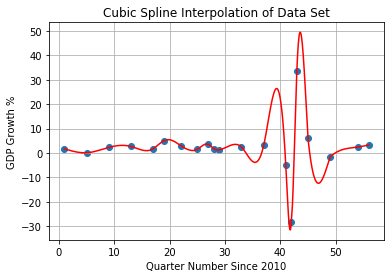

In [24]:
#1.

xint, yint = cubic_spline(x,y)

plt.figure()

plt.scatter(x, y) # Plotting the data points
plt.plot(xint, yint, 'red') # Plotting the line itself

plt.title(f"Cubic Spline Interpolation of Data Set")
plt.xlabel("Quarter Number Since 2010")
plt.ylabel("GDP Growth %")
plt.grid(True)
plt.show()

A cubic spline fits a cubic polynomial between each pair of consecutive data points. Because of the 20 data points, there are 19 seperate spline segments, and each segment has four coefficients, whcich gives us 76 total unknown coefficients. Instead of solving for all the coefficients directly, the spline is written in terms of the second derivatives at the data points, which is denoted by M_i = S"(x_i). Because a spline requires the second derivatives as the first and last data points to be zero, there are technically 18 unknown second derivatives to solve for.

At each interior data point, the spline must satisfy continuity. This means that the function values must match so the curve passes through each point. The first derivatives must match so the slope does not change jarringly between the segments. The second derivatives must also match so the curvature is continuous. These conditions will make sure that the spline is smooth across the entire range/data set.

The natural spline boundary conditions specify that the second derivative at the first and last data points is zero. This makes the spline behave linearly at the ends and provides the additional equations that I will need to solve the system.

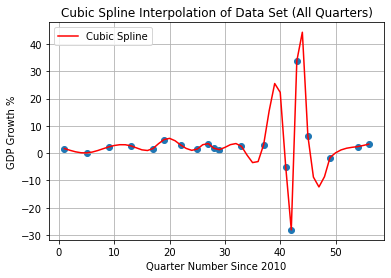

In [26]:
#2.

def cubic_spline_eval(x, y, x_eval): #This version loops over each spline interval and fills in all matching evaluation points at once, letting you compute the spline on an entire grid (like x_all) instead of evaluating one point at a time.

    
    a, b, c, d = tridiagonal_matrix(x, y)
    M_inner = thomas_algorithm(a.copy(), b.copy(), c.copy(), d.copy())
    M = np.array([0.0, *M_inner, 0.0])

    y_eval = np.zeros_like(x_eval, dtype=float)

    for i in range(len(x) - 1):
        mask = (x_eval >= x[i]) & (x_eval <= x[i+1])
        xs = x_eval[mask]
        h = x[i+1] - x[i]

        y_eval[mask] = (
            (M[i]/(6*h)) * (x[i+1]-xs)**3 +
            (M[i+1]/(6*h)) * (xs-x[i])**3 +
            (y[i]/h - M[i]*h/6) * (x[i+1]-xs) +
            (y[i+1]/h - M[i+1]*h/6) * (xs-x[i])
        )

    return y_eval



x_all = np.arange(x[0], x[-1] + 1)

y_all = cubic_spline_eval(x,y,x_all)

plt.figure()
plt.scatter(x, y) # Plotting the data set
plt.plot(x_all, y_all, 'red', label = 'Cubic Spline') # Plotting the line itself

plt.legend()
plt.title(f"Cubic Spline Interpolation of Data Set (All Quarters)")
plt.xlabel("Quarter Number Since 2010")
plt.ylabel("GDP Growth %")
plt.grid(True)
plt.show()

The natural cubic spline interpolant is mathematically smooth. It is C^2,  which means the function, its first, and second derivative are all continuous across the entire range. But, when I evaluate the spline at every quarter between 2010 Q1 and 2023 Q4, the resulting curve does not look gently smooth. The GDP growth data themselves are quite unusual and jarring, with sharp changes and at least one extreme outlier (2020 Q2 at -28.1%). Because the spline is forced to pass exactly through every data point, it must bend aggressively to hit these values. As a result, the interpolant, while technically smooth in the mathematical sense, appears visually jagged or wiggly in several regions. In that sense, the spline is not entirely visually smooth, and its behavior between points may not always look economically reasonable, especially near the extreme outlier.

#3.

The spline must pass exactly through the 2020 Q2 value (−28.1%), which is a major outlier. Forcing an exact interpolant through such an extreme point creates large curvature and makes the spline look jagged near that region. This relates to the Runge phenomenon which states that exact interpolation of data with sharp jumps or outliers can cause oscillations and unstable behavior between points. Because of this, exact interpolation is not always the best choice. For this dataset, weighted least squares would be preferable to an exact cubic spline because it reduces the impact of the extreme −28.1% outlier and produces a more stable looking curve.

## Part B - Polynomial and Least Squares Comparison

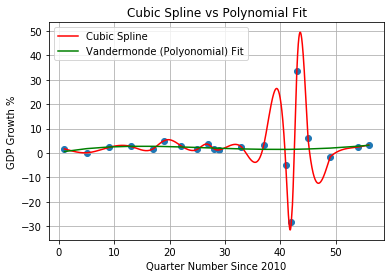

Spline RMSE: 1.0438642842512672e-15
Polynomial RMSE: 10.031440678677116


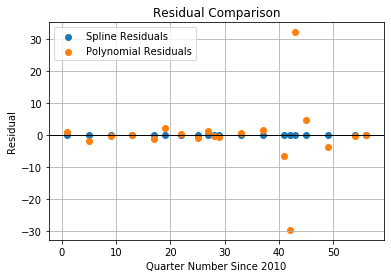

In [27]:
#1. 

vy = vanderm(x,y) #polyfitting using vandermonde

plt.figure()

plt.scatter(x, y) # Plotting the data points
plt.plot(xint, yint, 'red', label = 'Cubic Spline') # Plotting the Cubic Spline line itself
plt.plot(x, vy, color='green', label="Vandermonde (Polyonomial) Fit") # Plotting the Poly fit line

plt.legend()
plt.title(f"Cubic Spline vs Polynomial Fit")
plt.xlabel("Quarter Number Since 2010")
plt.ylabel("GDP Growth %")

plt.grid(True)
plt.show()

# Quantitative comparison of models
# Residuals
res_spline = y - cubic_spline_eval(x, y, x)       # spline evaluated at original x
res_poly   = y - vy                               # polynomial residuals

# RMSE
rmse_spline = np.sqrt(np.mean(res_spline**2))
rmse_poly   = np.sqrt(np.mean(res_poly**2))

print("Spline RMSE:", rmse_spline)
print("Polynomial RMSE:", rmse_poly)

# Residual plots
plt.figure()
plt.scatter(x, res_spline, label="Spline Residuals")
plt.scatter(x, res_poly, label="Polynomial Residuals")
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.title("Residual Comparison")
plt.xlabel("Quarter Number Since 2010")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

The degree‑4 polynomial provides a smooth overall trend but does not match individual data points closely. The cubic spline hits every data point exactly and captures local behavior better. Residual analysis shows spline RMSE = 1.0 * 10^-15, while the polynomial RMSE = 10.03, which indicates that the spline fits the data far more closely. The polynomial residuals show large structure and extreme deviations, while the spline residuals cluster tightly around zero. Therefore, the spline is  better for pointwise accuracy, while the polynomial is better for capturing a broad trend.

Slope: -0.001906988188976378


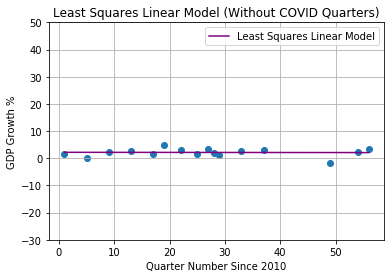

In [18]:
#2.

xc = np.array ([1,5,9,13,17,19,22,25,27,28,29,33,37,41,42,43,45,49,54,56]) # months
yc = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3]) #GDP Growth

remove = [13,14,15,16]

x_nc = np.delete(xc, remove) # removing covid quarters
y_nc = np.delete(yc, remove) # removing covid GDP growth/decay %
m, b = LeastSQ (x_nc,y_nc)

ylsq = m*x_nc + b

plt.figure()
plt.scatter(x_nc, y_nc) # Plotting the non-covid data points
plt.plot(x_nc, ylsq, 'purple', label = 'Least Squares Linear Model') # Plotting the LSQ itself

plt.legend()
plt.title(f"Least Squares Linear Model (Without COVID Quarters)")
plt.xlabel("Quarter Number Since 2010")
plt.ylabel("GDP Growth %")
plt.grid(True)
plt.ylim(-30, 50)
plt.show()

Removing the COVID quarters and fitting a linear model produced a slope of approximately −0.0019, indicating a nearly flat long‑run trend. A linear trend is only reasonable as a coarse summary because it assumes constant growth rates, independent errors, and no structural breaks. These assumptions are more plausible once the extreme COVID values are removed, but the model still cannot capture the cyclical nature of GDP growth.


## Part C — Method Justification

#1.

A policymaker estimating GDP growth between two known quarters requires a method that is locally accurate, smooth, and stable.
A cubic spline satisfies these requirements because it enforces continuity of value, slope, and curvature and uses only nearby data to determine the shape of each segment. A degree‑4 polynomial is a global approximation whose behavior between two points is influenced by all data, including distant outliers such as the −28.1% COVID quarter. Residual and RMSE analysis shows that the spline achieves near‑zero error at the data points, while the polynomial exhibits large structured residuals and an RMSE of approximately 10.03. The spline therefore provides more reliable and precise interpolation, especially in regions unaffected by extreme values. For these reasons, I recommend the cubic spline for interpolation because it provides the most accurate, smooth, and locally stable estimate between two known quarters and is far less sensitive to outliers than a global polynomial fit.

#2 (addendum). 

Big‑O notation describes how an algorithm’s running time grows as the size of the input increases. It keeps only the dominant term and ignores constants, so it captures the overall scaling behavior rather than exact runtimes. In this assignment, all three methods—cubic spline interpolation, degree‑4 polynomial fitting, and linear least squares—have essentially the same computational complexity: fitting each model is O(n), and evaluating the resulting function at a point is (1). Because their Big‑O performance is nearly identical, computational efficiency does not influence the choice of method. For a policymaker who needs to estimate GDP growth between two known quarters, the cubic spline remains the better option. It is a local interpolant, meaning it uses only nearby data to produce a smooth and accurate estimate between the two points, and it is not distorted by outliers elsewhere in the dataset. A degree‑4 polynomial is a global approximation: every data point affects the entire curve, so extreme values—such as the COVID quarters—can bend the polynomial even in regions where the data is otherwise well‑behaved. Therefore, although the algorithms have similar Big‑O complexity, the cubic spline provides more reliable, stable, and accurate interpolation for quarter‑to‑quarter policymaking needs.

## Conclusion

The cubic spline gave the most accurate local fit, with near‑zero residuals and reliable estimates between observed quarters. The degree‑4 polynomial captured a smooth overall trend but had large residuals and an RMSE around 10, making it less accurate for quarter‑to‑quarter behavior. The least squares linear model (without COVID quarters) showed an almost flat trend, which works only as a rough long‑term summary. Overall, splines are best for interpolation, while polynomial and least squares methods are better for broad trend analysis or reducing the impact of outliers.